## import

In [4]:
import pandas as pd
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt

## Data Load

In [2]:
df = pd.read_excel("C:/Users/jwChoi/Desktop/Data/ar-2017-2018.xlsx","Anonymised register")
# 모든 열 출력 설정
column_list = df.columns.tolist()
for i in range(0, len(column_list), 5):
    print(", ".join(column_list[i:i+5]))

Patient age at treatment, Total number of previous IVF cycles, Total number of previous DI cycles, Total number of previous pregnancies - IVF and DI, Total number of previous live births - IVF or DI
Causes of infertility - tubal disease, Causes of infertility - ovulatory disorder, Causes of infertility - male factor, Causes of infertility - patient unexplained, Causes of infertility - endometriosis
Main reason for producing embroys storing eggs, Stimulation used, Egg donor age at registration, Sperm donor age at registration, Donated embryo
Type of treatment - IVF or DI, Specific treatment type, PGT-M treatment, PGT-A treatment, Elective single embryo transfer
Egg source, Sperm source, Fresh cycle, Frozen cycle, Eggs thawed (0/1)
Fresh eggs collected, Fresh eggs stored (0/1), Total eggs mixed, Total embryos created, Embryos transferred
Total embryos thawed, Embryos transferred from eggs micro-injected, Embryos stored for use by patient, Date of embryo transfer, Year of treatment
Live b

In [3]:
len(column_list)

61

##### 결측치 시각화

Patient age at treatment                                  0
Total number of previous IVF cycles                       0
Total number of previous DI cycles                        0
Total number of previous pregnancies - IVF and DI    126928
Total number of previous live births - IVF or DI      64529
                                                      ...  
Heart three delivery date                            169536
Patient ethnicity                                         0
Partner ethnicity                                         0
Partner Type                                          10176
Partner age                                           16933
Length: 61, dtype: int64


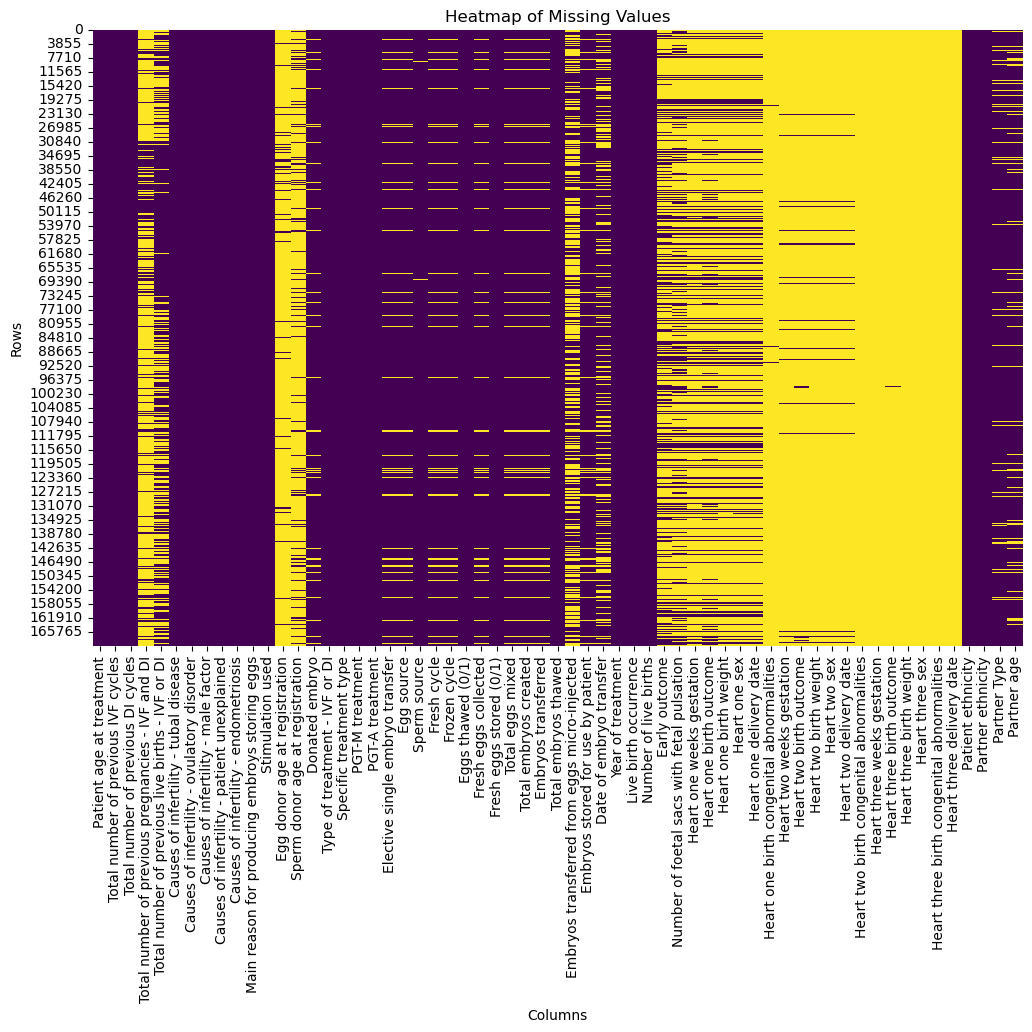

In [5]:
print(df.isnull().sum()) # 결측치 개수 출력

# 결측치 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## Data Type: number, text, bit
#### 결측값 조금만 있는 애들은 살리자
#### number: 행 날리기기
#### text: "Unknown"

In [7]:
# 결측치 비율 계산
missing_ratio = df.isnull().mean()
print(missing_ratio)

# 결측치 비율이 10% 이하인 열만 보존존
threshold = 0.1
columns_keep = missing_ratio[missing_ratio <= threshold].index
df_filtered = df[columns_keep]
df_filtered

Patient age at treatment                             0.000000
Total number of previous IVF cycles                  0.000000
Total number of previous DI cycles                   0.000000
Total number of previous pregnancies - IVF and DI    0.748326
Total number of previous live births - IVF or DI     0.380442
                                                       ...   
Heart three delivery date                            0.999528
Patient ethnicity                                    0.000000
Partner ethnicity                                    0.000000
Partner Type                                         0.059994
Partner age                                          0.099831
Length: 61, dtype: float64


,Patient age at treatment,Total number of previous IVF cycles,Total number of previous DI cycles,Causes of infertility - tubal disease,Causes of infertility - ovulatory disorder,Causes of infertility - male factor,Causes of infertility - patient unexplained,Causes of infertility - endometriosis,Main reason for producing embroys storing eggs,Stimulation used,...,Embryos transferred,Total embryos thawed,Embryos stored for use by patient,Year of treatment,Live birth occurrence,Number of live births,Patient ethnicity,Partner ethnicity,Partner Type,Partner age
0,45-50,3,0,0,0,0,0,0,Embryo storage,0,...,0.0,0,0,2017,0,0,Black,Other,Male,NaN
1,18-34,0,0,0,0,0,0,0,Donation,1,...,0.0,0,0,2018,0,0,White,Other,NaN,NaN
2,999,0,0,0,0,0,0,0,Donation,1,...,0.0,0,0,2018,0,0,Other,Other,NaN,NaN
3,18-34,0,0,0,0,1,0,0,Treatment - IVF,1,...,1.0,0,1-5,2018,0,0,White,White,Male,18-34
4,18-34,1,0,0,0,1,0,0,Treatment - IVF,0,...,1.0,1-5,0,2018,0,0,White,White,Male,18-34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169611,18-34,0,0,1,0,0,0,0,Treatment - IVF,1,...,1.0,0,1-5,2017,0,0,Other,White,Male,18-34
169612,18-34,1,0,1,0,0,0,0,Treatment - IVF,0,...,1.0,1-5,0,2017,0,0,Other,White,Male,18-34
169613,18-34,2,0,1,0,0,0,0,Treatment - IVF,0,...,2.0,1-5,0,2017,1,1,Other,White,Male,18-34
169614,35-37,0,0,0,0,1,0,0,Treatment - IVF,1,...,1.0,0,1-5,2017,1,1,Other,Other,Male,35-37


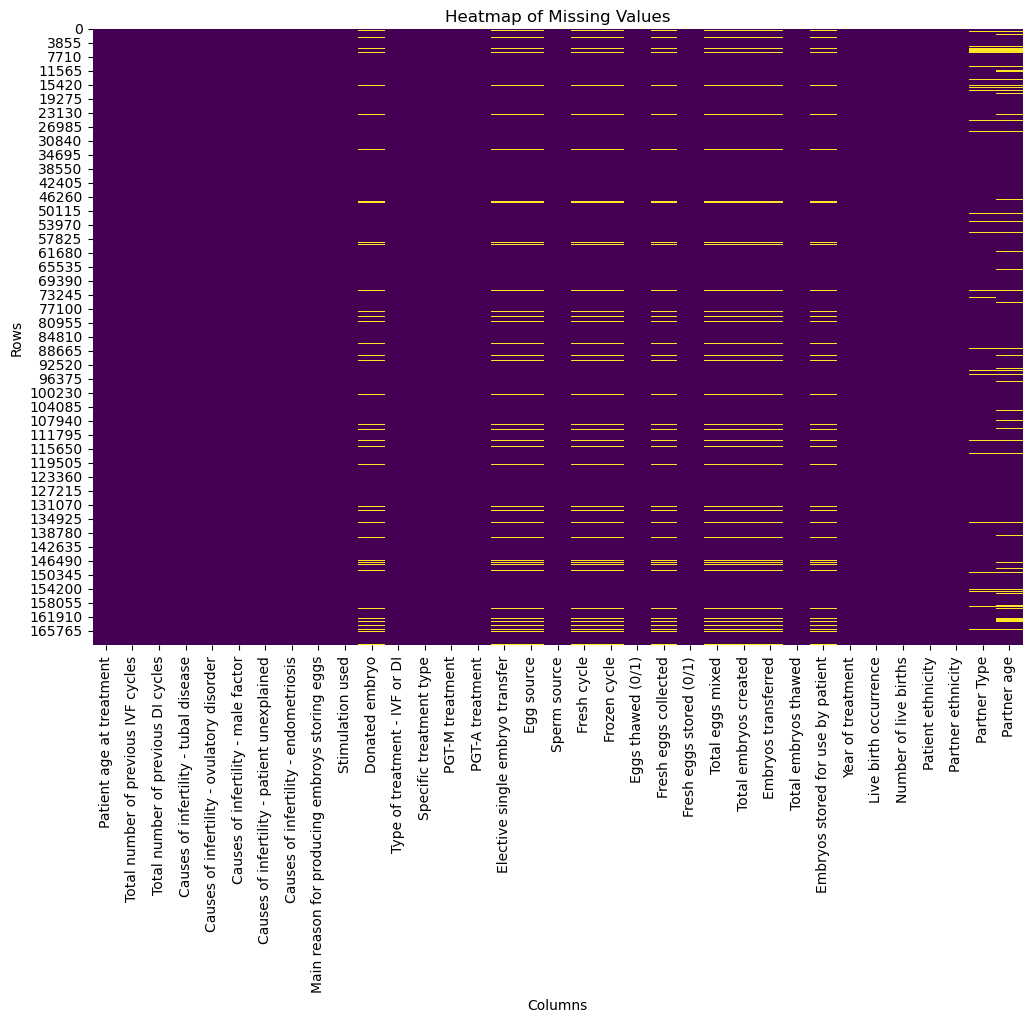

In [8]:
# 결측치 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [9]:
df_filtered.dtypes

Patient age at treatment                           object
Total number of previous IVF cycles                object
Total number of previous DI cycles                 object
Causes of infertility - tubal disease               int64
Causes of infertility - ovulatory disorder          int64
Causes of infertility - male factor                 int64
Causes of infertility - patient unexplained         int64
Causes of infertility - endometriosis               int64
Main reason for producing embroys storing eggs     object
Stimulation used                                    int64
Donated embryo                                    float64
Type of treatment - IVF or DI                      object
Specific treatment type                            object
PGT-M treatment                                     int64
PGT-A treatment                                     int64
Elective single embryo transfer                   float64
Egg source                                         object
Sperm source  

In [10]:
print(df_filtered.isnull().sum()) # 결측치 개수 출력

Patient age at treatment                              0
Total number of previous IVF cycles                   0
Total number of previous DI cycles                    0
Causes of infertility - tubal disease                 0
Causes of infertility - ovulatory disorder            0
Causes of infertility - male factor                   0
Causes of infertility - patient unexplained           0
Causes of infertility - endometriosis                 0
Main reason for producing embroys storing eggs        0
Stimulation used                                      0
Donated embryo                                    11282
Type of treatment - IVF or DI                         0
Specific treatment type                               0
PGT-M treatment                                       0
PGT-A treatment                                       0
Elective single embryo transfer                   11282
Egg source                                        11282
Sperm source                                    

In [11]:
# 숫자형 열
numerical_columns = df_filtered.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("숫자형 열:", numerical_columns)

# 범주형 열
categorical_columns = df_filtered.select_dtypes(include=['object']).columns.tolist()
print("범주형 열:", categorical_columns)

숫자형 열: ['Causes of infertility - tubal disease', 'Causes of infertility - ovulatory disorder', 'Causes of infertility - male factor', 'Causes of infertility - patient unexplained', 'Causes of infertility - endometriosis', 'Stimulation used', 'Donated embryo', 'PGT-M treatment', 'PGT-A treatment', 'Elective single embryo transfer', 'Fresh cycle', 'Frozen cycle', 'Eggs thawed (0/1)', 'Fresh eggs stored (0/1)', 'Embryos transferred', 'Year of treatment', 'Live birth occurrence', 'Number of live births']
범주형 열: ['Patient age at treatment', 'Total number of previous IVF cycles', 'Total number of previous DI cycles', 'Main reason for producing embroys storing eggs', 'Type of treatment - IVF or DI', 'Specific treatment type', 'Egg source', 'Sperm source', 'Fresh eggs collected', 'Total eggs mixed', 'Total embryos created', 'Total embryos thawed', 'Embryos stored for use by patient', 'Patient ethnicity', 'Partner ethnicity', 'Partner Type', 'Partner age']


#### 범주형 열의 결측치는 'Unknown'

In [12]:
df_filtered[categorical_columns] = df_filtered[categorical_columns].fillna('Unknown')

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_16772\3821339163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[categorical_columns] = df_filtered[categorical_columns].fillna('Unknown')


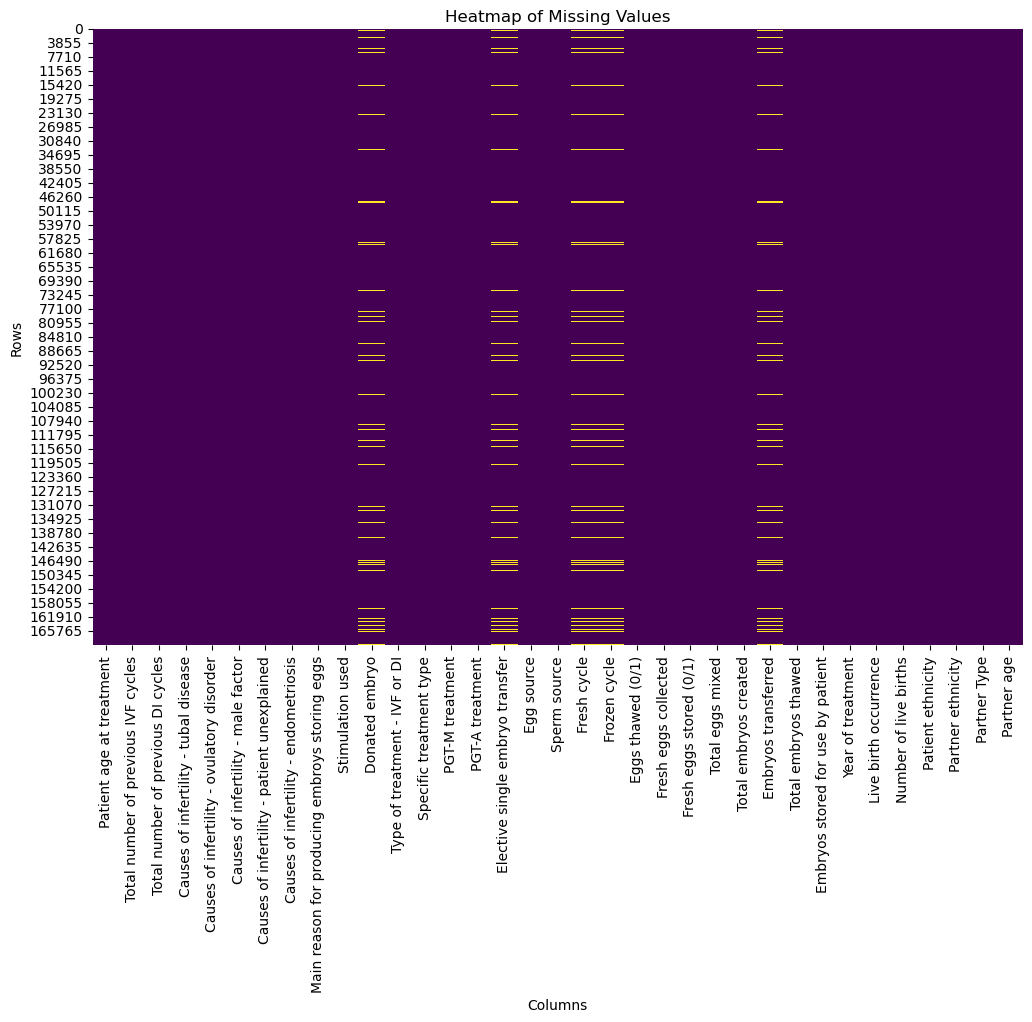

In [13]:
# 범주형 열 채운 결측치 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## 결측치 제거

In [14]:
df_filtered= df_filtered.dropna(subset=numerical_columns)

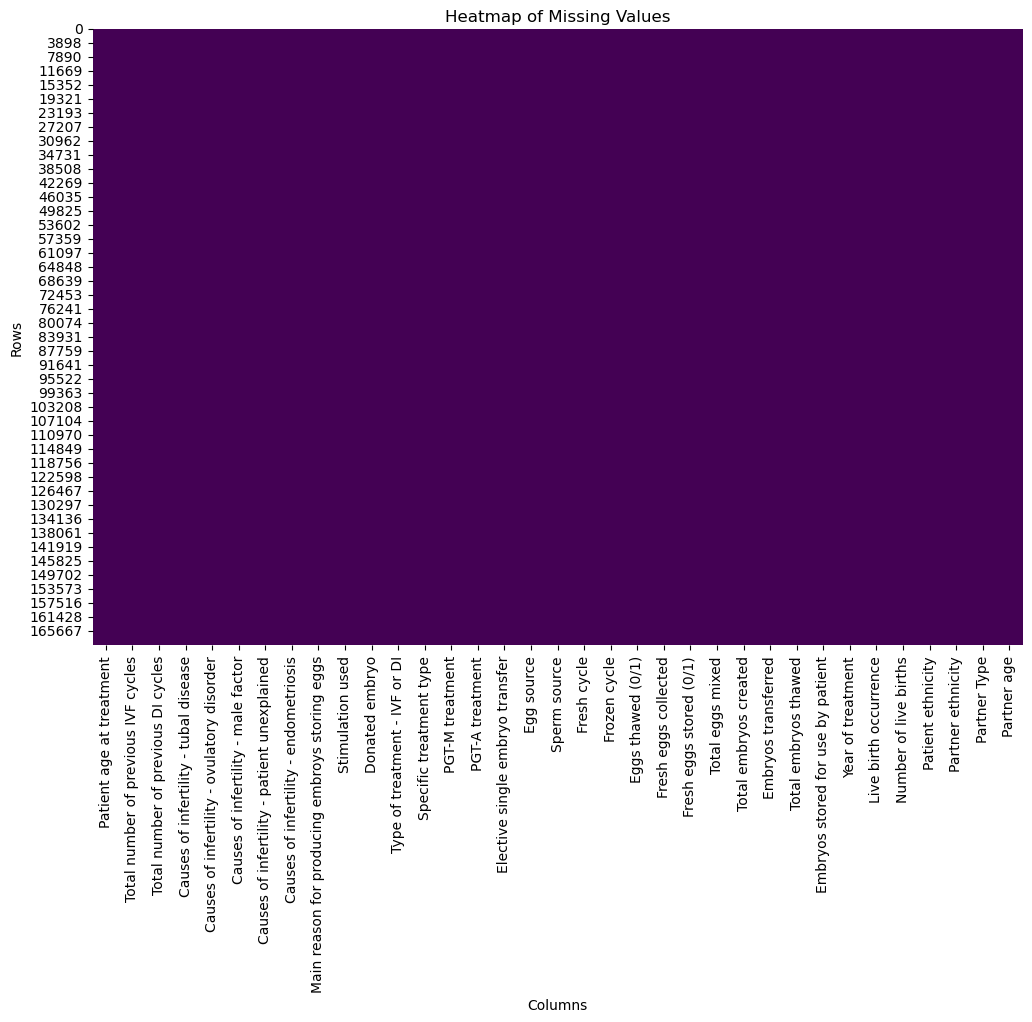

In [15]:
# 숫자형형 열 지운 결측치 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## 데이터 저장

In [16]:
df_filtered.to_excel('processed_data.xlsx', index=False, engine='openpyxl')

## 이상치 제거

In [19]:
df_cleaned = df_cleaned[df_cleaned['Patient age at treatment'] != 999]
df_cleaned['Patient age at treatment']

0         45-50
1         18-34
3         18-34
4         18-34
5         40-42
          ...  
169611    18-34
169612    18-34
169613    18-34
169614    35-37
169615    18-34
Name: Patient age at treatment, Length: 166947, dtype: object

## 범주형 데이터 찾기

In [18]:
categorical_colums=df_cleaned.select_dtypes(include=['object']).columns.tolist()
categorical_colums

['Patient age at treatment',
 'Total number of previous IVF cycles',
 'Total number of previous DI cycles',
 'Main reason for producing embroys storing eggs',
 'Type of treatment - IVF or DI',
 'Specific treatment type',
 'Total embryos thawed',
 'Patient ethnicity',
 'Partner ethnicity']

## 변수 선택


In [20]:
column_remove = ['Patient ethnicity', 'Partner ethnicity']
df_cleaned = df.drop(columns=column_remove, errors='ignore')
df_cleaned.columns

Index(['Patient age at treatment', 'Total number of previous IVF cycles',
       'Total number of previous DI cycles',
       'Total number of previous pregnancies - IVF and DI',
       'Total number of previous live births - IVF or DI',
       'Causes of infertility - tubal disease',
       'Causes of infertility - ovulatory disorder',
       'Causes of infertility - male factor',
       'Causes of infertility - patient unexplained',
       'Causes of infertility - endometriosis',
       'Main reason for producing embroys storing eggs', 'Stimulation used',
       'Egg donor age at registration', 'Sperm donor age at registration',
       'Donated embryo', 'Type of treatment - IVF or DI',
       'Specific treatment type', 'PGT-M treatment', 'PGT-A treatment',
       'Elective single embryo transfer', 'Egg source', 'Sperm source',
       'Fresh cycle', 'Frozen cycle', 'Eggs thawed (0/1)',
       'Fresh eggs collected', 'Fresh eggs stored (0/1)', 'Total eggs mixed',
       'Total embryos 

## 원핫인코딩

In [ ]:
def automate_one_hot_encoding(df, column, bins, labels, prefix=None):
    """
    특정 열을 범주화하고 원핫인코딩 수행.
    
    Args:
    - df (DataFrame): 데이터프레임
    - column (str): 범주화 및 원핫인코딩할 열 이름
    - bins (list): 범주화를 위한 구간 경계값
    - labels (list): 범주 이름
    - prefix (str): 원핫인코딩된 열의 접두사 (기본값: 원본 열 이름 사용)
    
    Returns:
    - DataFrame: 원핫인코딩이 적용된 데이터프레임
    """
    # 범주화
    df[f"{column}_category"] = pd.cut(df[column], bins=bins, labels=labels)
    
    # 원핫인코딩
    prefix = prefix if prefix else column
    df = pd.get_dummies(df, columns=[f"{column}_category"], prefix=prefix)
    
    return df

In [21]:
data = {'Patient age at treatment':['18-34', '35-37', '38-39', '40-42', '43-44', '45-50'],
 'Total number of previous IVF cycles':['0','1','2','3','4','5','5+'],
 'Total number of previous DI cycles':['0','1','2','3','4','5','5+'],
 'Main reason for producing embroys storing eggs':['Donation','Egg storage', 'Treatment - IVF', 'Treatment - DI', 'Embryo storage'],
 'Type of treatment - IVF or DI':['IVF', 'DI'],
 'Specific treatment type':['Unknown', 'IVF', 'DI', 'ICSI'],
 'Total embryos thawed':['0', '1-5', '6-10'],
 }
df_cleaned = pd.DataFrame(data)

encoder = OneHotEncoder(sparse=False)
encoded_array = encoder.fit_transform(df_cleaned[['Patient age at treatment',
 'Total number of previous IVF cycles',
 'Total number of previous DI cycles',
 'Main reason for producing embroys storing eggs',
 'Type of treatment - IVF or DI',
 'Specific treatment type',
 'Total embryos thawed']])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out())
encoded_df

ValueError: All arrays must be of the same length

## 레이블 인코딩

In [ ]:
class label_encode:
    def __init__(self):
        self.label_id = {}
        self.inital_format = {"id" : 0, "count" : 1}
        self.cur_id = 0
    
    def encode(self, datas:list):
        return_labels = []
        for data in datas:
            ch = self.label_id.get(data)
            if ch is not None:
                self.label_id[data]["count"] += 1
                return_labels.append(self.label_id[data]["id"])
            else:
                self.label_id[data] = self.inital_format.copy()
                self.label_id[data]["id"] = self.cur_id
                return_labels.append(self.label_id[data]["id"])
                self.cur_id += 1

        return return_labels

        
    def __call__(self, datas):
        return self.encode(datas)